In [22]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

from DMTimeShardDataset import DMTimeShardDataset
import training
import training_models
from ensemble import TorchRejectionEnsemble
from skrejector import SNRDT_Rejector
from embedding_processing_models import build_embedding_processing
from rejector import EmbeddingRejector
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


Device: cuda


In [23]:
dataset_cfg = {
    'output_dir': '/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs', 
    'prefix': 'B0531+21_59000_48386'
}

f_small_weights = '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/finetune_checkpoints/prot-DM_time_binary_classificator_241002_3_GAP_finetune-004-0.838-0.813.pth'
f_mid_weights = '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/finetune_checkpoints/prot-DM_time_binary_classificator_241002_5_GAP_finetune-019-0.989-0.993.pth'
f_large_weights = '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/finetune_checkpoints/prot-DM_time_binary_classificator_resnet18_finetune-010-0.999-0.993.pth'

print('Loading small model...')
small_model = training_models.models_htable['DM_time_binary_classificator_241002_3_GAP'](256, mode='dmt', dropout=False, device=device).to(device)
small_model.load_state_dict(torch.load(f_small_weights, map_location=device)['model_state_dict'])
small_model.eval()

print('Loading mid model...')
mid_model = training_models.models_htable['DM_time_binary_classificator_241002_5_GAP'](256, mode='ft', dropout=False, device=device).to(device)
mid_model.load_state_dict(torch.load(f_mid_weights, map_location=device)['model_state_dict'])
mid_model.eval()

print('Loading large model...')
large_model = training_models.models_htable['DM_time_binary_classificator_resnet18'](256, mode="dmft", dropout=False, device=device).to(device)
large_model.load_state_dict(torch.load(f_large_weights, map_location=device)["model_state_dict"])
large_model.eval()


Loading small model...
Loading mid model...
Loading large model...


DMTimeBinaryClassificatorResNet18(
  (dropout_conv): Identity()
  (dropout_fc): Identity()
  (backbone): ResNet(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (dropout_fc): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (dropout): Identity()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64,

In [24]:
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint


def get_rejector_state_dict(ckpt):
    """Normalize different checkpoint formats to the rejector model's state_dict."""
    state_dict = extract_state_dict(ckpt)

    if not isinstance(state_dict, dict):
        return state_dict

    clean_dict = {}

    for k, v in state_dict.items():
        if k.startswith("1.net."):
            clean_dict["net." + k[len("1.net."):]] = v
        elif k.startswith("1."):
            clean_dict[k[len("1."):]] = v
        elif k.startswith("embedding_processing."):
            clean_dict[k[len("embedding_processing."):]] = v

    return clean_dict or state_dict

targets_file = "artifacts/routing_targets/unbalanced_val_routing_targets_cascaded_r2_r1filtered_FINETUNE.npz"

if os.path.exists(targets_file):
    print("Loading existing unbalanced R2 routing targets...")

    cached = np.load(targets_file)
    routing_targets_val_np = cached["routing_targets_val"]
    val_indices_r2 = cached["val_indices_r2"]

    pulse_val_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split="val")
    pulse_val_dataset.labels = training.label_encoding(pulse_val_dataset.labels.astype(object))

    # Wichtig: Für R2 ist der Val-Loader nur der R1-gefilterte Subset,
    # nicht der komplette Val-Datensatz.
    pulse_val_loader = DataLoader(
        Subset(pulse_val_dataset, val_indices_r2),
        batch_size=1024,
        shuffle=False,
        num_workers=2,
    )

else:
    print("Generating unbalanced R2 routing targets with full cascaded setup...")

    # ----------------------------
    # Datasets
    # ----------------------------
    pulse_train_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split="val") #VAL INSTEAD OF TRAIN! CURRENTLY JUST NEED THAT AS PLACEHOLDER
    pulse_train_dataset.labels = training.label_encoding(pulse_train_dataset.labels.astype(object))

    pulse_val_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split="val")
    pulse_val_dataset.labels = training.label_encoding(pulse_val_dataset.labels.astype(object))

    pulse_train_loader_uncut = DataLoader(
        pulse_train_dataset,
        batch_size=1024,
        shuffle=False,
        num_workers=2,
    )

    pulse_val_loader_uncut = DataLoader(
        pulse_val_dataset,
        batch_size=1024,
        shuffle=False,
        num_workers=2,
    )

    # ----------------------------
    # Base models laden
    # ----------------------------
    small_model = training_models.models_htable[
        "DM_time_binary_classificator_241002_3_GAP"
    ](256, mode="dmt", dropout=False, device=device).to(device)
    small_model.load_state_dict(
        torch.load(f_small_weights, map_location=device)["model_state_dict"]
    )
    small_model.eval()

    mid_model = training_models.models_htable[
        "DM_time_binary_classificator_241002_5_GAP"
    ](256, mode="ft", dropout=False, device=device).to(device)
    mid_model.load_state_dict(
        torch.load(f_mid_weights, map_location=device)["model_state_dict"]
    )
    mid_model.eval()

    large_model = training_models.models_htable[
        "DM_time_binary_classificator_resnet18"
    ](256, mode="dmft", dropout=False, device=device).to(device)
    large_model.load_state_dict(
        torch.load(f_large_weights, map_location=device)["model_state_dict"]
    )
    large_model.eval()

    # ----------------------------
    # R1-Rejector laden
    # ----------------------------
    r1_ckpt_path = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/finetune_checkpoints/prot-run_embedding_r1_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker3_trial0-030-0.688-0.618.pth"

    r1_kwargs = {
        "model_name": "conv_mlp",
        "cnn_channels": 64,
        "extra_conv": False,
        "pool_size": 7,
        "hidden_dim": 64,
    }

    embedding_processing, feature_source = build_embedding_processing(
        in_channels=12,
        **r1_kwargs,
    )
    embedding_processing = embedding_processing.to(device)
    embedding_processing.eval()

    r1_ckpt = torch.load(r1_ckpt_path, map_location=device)
    embedding_processing.load_state_dict(get_rejector_state_dict(r1_ckpt))

    r1 = EmbeddingRejector(
        small_model,
        embedding_processing,
        device,
        feature_source=feature_source,
    )

    # ----------------------------
    # Cascaded Ensemble wie in der Praxis
    # ----------------------------
    rejection_ensemble = TorchRejectionEnsemble(
        small_model,
        mid_model,
        p=0.8,
        rejector=r1,
        calibration=False,
        reject_threshold_r1=0.548808,
    )

    # ----------------------------
    # Unbalanced R2 Targets erzeugen
    # ----------------------------
    (
        routing_targets_train,
        routing_targets_val,
        mid_train_logits_sub,
        mid_val_logits_sub,
        _large_train_logits_sub,
        _large_val_logits_sub,
        _Y_train_sub,
        _Y_val_sub,
        train_mask_r1,
        val_mask_r1,
    ) = rejection_ensemble.prepare_fit_r2(
        pulse_train_loader_uncut,
        pulse_val_loader_uncut,
        large_model,
        return_debug=True,
    )

    routing_targets_val_np = (
        routing_targets_val.cpu().numpy()
        if torch.is_tensor(routing_targets_val)
        else np.asarray(routing_targets_val)
    )

    val_indices_r2 = np.where(val_mask_r1)[0]

    # Loader passend zu den R2-Targets.
    # Also nur Samples, die von R1 weitergeleitet wurden.
    pulse_val_loader = DataLoader(
        Subset(pulse_val_dataset, val_indices_r2),
        batch_size=1024,
        shuffle=False,
        num_workers=2,
    )

    np.savez(
        targets_file,
        routing_targets_val=routing_targets_val_np,
        val_indices_r2=val_indices_r2,
    )

y_true = np.asarray(routing_targets_val_np).astype(int)

print(f"Done! Unbalanced R2 true routing labels loaded, shape: {y_true.shape}")
print(f"R2 val subset size: {len(pulse_val_loader.dataset)}")
print(f"Reject target ratio: {y_true.mean():.4f}")

# Hole die echten Klassen (Metadaten: "-1=rest of events", "0=zero DM", "1=pulse") für R2 Samples 
metadata_val_path = "/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs/B0531+21_59000_48386_DM_time_dataset_realbased_metadata_val.npy"

if os.path.exists(metadata_val_path):
    metadata_val = np.load(metadata_val_path)
    metadata_r2 = metadata_val[val_indices_r2]
    
    label_map = {
        -1.0: "rest of events",
        0.0: "zero DM events",
        1.0: "pulses",
    }
    
    unique, counts = np.unique(metadata_r2[:, 4], return_counts=True)
    total_meta = int(counts.sum())
    print("\n--- R2 Filtered Subset Classes (from Metadata) ---")
    for value, count in sorted(zip(unique, counts), key=lambda x: x[0]):
        name = label_map.get(float(value), f"unknown({value})")
        share = count / total_meta if total_meta else 0.0
        print(f"  {name:>16}: {count:5d} ({share:.2%})")
    print(f"  {'total':>16}: {total_meta:5d} (100.00%)")
else:
    actual_labels = pulse_val_dataset.labels[val_indices_r2]
    class_0_r2 = (actual_labels == 0).sum()
    class_1_r2 = (actual_labels == 1).sum()
    total_r2 = len(actual_labels)

    print(f"\n--- R2 Filtered Subset Classes ---")
    print(f"Noise (0):  {class_0_r2} ({class_0_r2/total_r2:.4f})")
    print(f"Signal (1): {class_1_r2} ({class_1_r2/total_r2:.4f})")

Loading existing unbalanced R2 routing targets...
Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
Done! Unbalanced R2 true routing labels loaded, shape: (49431,)
R2 val subset size: 49431
Reject target ratio: 0.0573

--- R2 Filtered Subset Classes (from Metadata) ---
    rest of events: 22038 (44.58%)
    zero DM events:  6339 (12.82%)
            pulses: 21054 (42.59%)
             total: 49431 (100.00%)


In [25]:
rejector_checkpoints = {
    "conv_mlp": {
        "path": "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/finetune_checkpoints/prot-run_embedding_r2_conv_mlp_lr4.51e-05_wd0.00e+00_drop0.2_channels64_extraTrue_pool7_hidden128_worker0_trial0-017-0.800-0.834.pth",
        "kwargs": {"model_name": "conv_mlp", "cnn_channels": 64, "extra_conv": True, "pool_size": 7, "hidden_dim": 128}
    }
}


In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    auc,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint


def get_rejector_state_dict(ckpt):
    state_dict = extract_state_dict(ckpt)

    clean_dict = {}
    for k, v in state_dict.items():
        if k.startswith("1.net."):
            clean_dict["net." + k[len("1.net."):]] = v
        elif k.startswith("1."):
            clean_dict[k[len("1."):]] = v
        elif k.startswith("embedding_processing."):
            clean_dict[k[len("embedding_processing."):]] = v

    if len(clean_dict) == 0:
        return state_dict

    return clean_dict


def compute_pr_curve_from_scores(y_true, scores):
    """
    y_true:
        1 = reject, also f_large routen
        0 = accept, also f_mid benutzen

    scores:
        größerer Score = stärkerer Hinweis auf reject
        (hier: reject probability in [0, 1])
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # Average Precision ist die übliche PR-Metrik bei Imbalance.
    ap = average_precision_score(y_true, scores)

    # Optional: trapezförmige Fläche unter der gezeichneten Kurve.
    # Nicht identisch zu AP, aber manchmal als PR-AUC berichtet.
    pr_auc_trapz = auc(recall, precision)

    positive_rate = y_true.mean()

    return precision, recall, thresholds, ap, pr_auc_trapz, positive_rate


def print_threshold_metrics(y_true, scores, threshold=0.5):
    """
    threshold bezieht sich auf reject probability in [0, 1].
    threshold = 0.5 entspricht argmax.
    """
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)

    y_pred = (scores >= threshold).astype(int)

    precision_r = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_r = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    reject_rate = y_pred.mean()
    positive_rate = y_true.mean()

    print(f"\nMetrics at threshold = {threshold:.4f}")
    print(f"Positive rate / true reject share: {positive_rate:.4f}")
    print(f"Predicted reject rate:            {reject_rate:.4f}")
    print(f"Precision reject=1:               {precision_r:.4f}")
    print(f"Recall reject=1:                  {recall_r:.4f}")
    print(f"F1 reject=1:                      {f1_r:.4f}")
    print()
    print("Confusion matrix for routing target")
    print("Rows = true, columns = predicted")
    print("          pred_accept   pred_reject")
    print(f"true_accept   {tn:10d}   {fp:11d}")
    print(f"true_reject   {fn:10d}   {tp:11d}")

    return {
        "threshold": threshold,
        "positive_rate": positive_rate,
        "reject_rate": reject_rate,
        "precision_reject": precision_r,
        "recall_reject": recall_r,
        "f1_reject": f1_r,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def evaluate_rejector_model(model_name):
    print(f"\n--- Evaluating {model_name} ---")
    info = rejector_checkpoints[model_name]

    rej_model, hook = build_embedding_processing(in_channels=12, **info["kwargs"])
    rej_model.to(device)
    rej_model.eval()

    ckpt = torch.load(info["path"], map_location=device)
    rej_model.load_state_dict(get_rejector_state_dict(ckpt))

    all_logits = []

    small_model.eval()

    mid_model.eval()

    with torch.no_grad():
        for batch in tqdm(pulse_val_loader):
            data_input = mid_model.features(batch)

            if data_input.dim() == 3:
                data_input = data_input.unsqueeze(0)

            features = getattr(mid_model, hook)(data_input)

            if features.dim() == 3:
                features = features.unsqueeze(0)
            elif hook == "pooled_features" and features.dim() == 1:
                features = features.unsqueeze(0)

            logits = rej_model(features)
            all_logits.append(logits.detach().cpu().numpy())

    logits_np = np.concatenate(all_logits, axis=0)

    if logits_np.shape[0] != len(y_true):
        raise ValueError(
            f"Logit count {logits_np.shape[0]} does not match labels {len(y_true)}. "
            "Prüfe, ob y_true exakt aus demselben Val-Loader in derselben Reihenfolge stammt "
            "und ob pulse_val_loader shuffle=False verwendet."
        )

    # Klasse 1 ist reject.
    # scores sind reject probabilities in [0, 1].
    scores = torch.softmax(torch.from_numpy(logits_np), dim=1).numpy()[:, 1]

    precision, recall, thresholds, ap, pr_auc_trapz, positive_rate = compute_pr_curve_from_scores(
        y_true, scores
    )

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, lw=2, label=f"{model_name} (AP = {ap:.4f})")
    plt.axhline(
        positive_rate,
        linestyle="--",
        label=f"Random baseline = {positive_rate:.4f}"
    )
    plt.xlabel("Recall for reject class")
    plt.ylabel("Precision for reject class")
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

    print(f"Positive rate / true reject share: {positive_rate:.4f}")
    print(f"Average Precision AP:             {ap:.4f}")
    print(f"Trapezoidal PR-AUC:               {pr_auc_trapz:.4f}")

    threshold_0_metrics = print_threshold_metrics(y_true, scores, threshold=0.5)

    return {
        "model_name": model_name,
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "scores": scores,
        "ap": ap,
        "pr_auc_trapz": pr_auc_trapz,
        "positive_rate": positive_rate,
        "threshold_0_metrics": threshold_0_metrics,
    }


--- Evaluating conv_mlp ---


  0%|          | 0/49 [00:00<?, ?it/s]

100%|██████████| 49/49 [01:04<00:00,  1.31s/it]


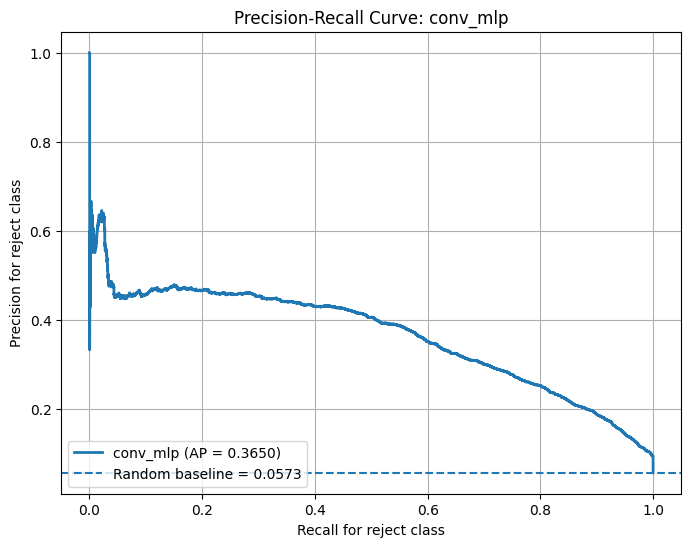

Positive rate / true reject share: 0.0573
Average Precision AP:             0.3650
Trapezoidal PR-AUC:               0.3647

Metrics at threshold = 0.5000
Positive rate / true reject share: 0.0573
Predicted reject rate:            0.2481
Precision reject=1:               0.2030
Recall reject=1:                  0.8786
F1 reject=1:                      0.3298

Confusion matrix for routing target
Rows = true, columns = predicted
          pred_accept   pred_reject
true_accept        36821          9776
true_reject          344          2490


{'model_name': 'conv_mlp',
 'precision': array([0.05733244, 0.0573336 , 0.05733476, ..., 0.5       , 1.        ,
        1.        ]),
 'recall': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        3.52858151e-04, 3.52858151e-04, 0.00000000e+00]),
 'thresholds': array([1.48527718e-11, 1.36307424e-10, 1.05565379e-09, ...,
        9.00029719e-01, 9.02591109e-01, 9.04272258e-01]),
 'scores': array([0.00196894, 0.38967997, 0.39477977, ..., 0.00304197, 0.7882403 ,
        0.01626784], dtype=float32),
 'ap': 0.36499302171800985,
 'pr_auc_trapz': 0.3646568948692662,
 'positive_rate': 0.05733244320365762,
 'threshold_0_metrics': {'threshold': 0.5,
  'positive_rate': 0.05733244320365762,
  'reject_rate': 0.24814387732394652,
  'precision_reject': 0.2030001630523398,
  'recall_reject': 0.8786167960479887,
  'f1_reject': 0.3298013245033113,
  'tn': 36821,
  'fp': 9776,
  'fn': 344,
  'tp': 2490}}

In [27]:
evaluate_rejector_model('conv_mlp')


# R2 operating point: Pareto curve, threshold mapping, latency

This section evaluates the **second rejector** on the uncut validation set with a fixed R1 threshold.  
The main operating variable is the **local R2 reject rate**:

\[
x = P(R_2 	ext{ rejects} \mid R_1 	ext{ rejected})
\]

This is the rate you should use to select the R2 threshold. The global share routed to `f_large` is:

\[
q = P(	ext{routed to } f_{large}) = P(R_1 	ext{ rejects}) \cdot x
\]


In [28]:
# ------------------------------------------------------------
# Cell 1: Collect validation predictions and R1/R2 reject scores
# ------------------------------------------------------------
# This cell computes and caches all predictions and reject scores needed for the Pareto analysis.
# Re-running the later cells does not require model inference again unless FORCE_RECOMPUTE=True.

import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

CACHE_FILE = "artifacts/operating_points/r2_operating_point_cache_val_FINETUNED.npz"
FORCE_RECOMPUTE = True

# Fixed R1 checkpoint + threshold
# IMPORTANT: r1_threshold is a score threshold, not the R1 reject rate.
r1_ckpt_path = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/finetune_checkpoints/prot-run_embedding_r1_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker3_trial0-030-0.688-0.618.pth"
r1_kwargs = {
    "model_name": "conv_mlp",
    "cnn_channels": 64,
    "extra_conv": False,
    "pool_size": 7,
    "hidden_dim": 64,
}
r1_threshold = 0.542446

# R2 checkpoint from rejector_checkpoints
r2_rejector_name = "conv_mlp"

if os.path.exists(CACHE_FILE) and not FORCE_RECOMPUTE:
    print(f"Loading cached validation scores from {CACHE_FILE} ...")
    cached = np.load(CACHE_FILE)
    r1_scores_np = cached["r1_scores_np"]
    r2_scores_np = cached["r2_scores_np"]
    r1_mask_np = cached["r1_mask_np"].astype(bool)
    small_preds_np = cached["small_preds_np"]
    mid_preds_np = cached["mid_preds_np"]
    large_preds_np = cached["large_preds_np"]
    labels_np = cached["labels_np"]
else:
    print("Computing validation predictions and rejector scores ...")

    # Load R2 rejector
    r2_info = rejector_checkpoints[r2_rejector_name]
    r2_model, r2_hook = build_embedding_processing(in_channels=12, **r2_info["kwargs"])
    r2_model.to(device)
    r2_model.eval()

    r2_ckpt = torch.load(r2_info["path"], map_location=device)
    r2_model.load_state_dict(get_rejector_state_dict(r2_ckpt))

    # Load R1 rejector
    r1_model, r1_hook = build_embedding_processing(in_channels=12, **r1_kwargs)
    r1_model.to(device)
    r1_model.eval()

    r1_ckpt = torch.load(r1_ckpt_path, map_location=device)
    r1_model.load_state_dict(get_rejector_state_dict(r1_ckpt))

    small_model.eval()
    mid_model.eval()
    large_model.eval()

    # Full / uncut validation loader
    if "pulse_val_dataset" not in globals():
        pulse_val_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split="val")
        pulse_val_dataset.labels = training.label_encoding(pulse_val_dataset.labels.astype(object))

    pulse_val_loader_uncut = DataLoader(
        pulse_val_dataset,
        batch_size=1024,
        shuffle=False,
        num_workers=2,
    )

    all_r1_scores = []
    all_r2_scores = []
    all_r1_masks = []
    all_small_preds = []
    all_mid_preds = []
    all_large_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(pulse_val_loader_uncut):
            labels = batch["label"].to(device)

            # f_small prediction
            small_input = small_model.features(batch)
            if small_input.dim() == 3:
                small_input = small_input.unsqueeze(0)
            small_logits = small_model.classifier(small_input)
            small_pred = small_logits.argmax(dim=1)

            # R1 score on f_small features
            r1_features = getattr(small_model, r1_hook)(small_input)
            if r1_features.dim() == 3:
                r1_features = r1_features.unsqueeze(0)
            elif r1_hook == "pooled_features" and r1_features.dim() == 1:
                r1_features = r1_features.unsqueeze(0)

            r1_logits = r1_model(r1_features)
            r1_scores = torch.softmax(r1_logits, dim=1)[:, 1].detach()
            r1_mask = r1_scores >= r1_threshold

            # f_mid prediction + R2 score
            # In the real cascade this is only needed for R1-rejected samples.
            # For analysis we compute it for all samples and mask later.
            mid_input = mid_model.features(batch)
            if mid_input.dim() == 3:
                mid_input = mid_input.unsqueeze(0)
            mid_logits = mid_model.classifier(mid_input)
            mid_pred = mid_logits.argmax(dim=1)

            r2_features = getattr(mid_model, r2_hook)(mid_input)
            if r2_features.dim() == 3:
                r2_features = r2_features.unsqueeze(0)
            elif r2_hook == "pooled_features" and r2_features.dim() == 1:
                r2_features = r2_features.unsqueeze(0)

            r2_logits = r2_model(r2_features)
            r2_scores = torch.softmax(r2_logits, dim=1)[:, 1].detach()

            # f_large prediction
            large_input = large_model.features(batch)
            if large_input.dim() == 3:
                large_input = large_input.unsqueeze(0)
            large_logits = large_model.classifier(large_input)
            large_pred = large_logits.argmax(dim=1)

            all_r1_scores.append(r1_scores.cpu())
            all_r2_scores.append(r2_scores.cpu())
            all_r1_masks.append(r1_mask.cpu())
            all_small_preds.append(small_pred.cpu())
            all_mid_preds.append(mid_pred.cpu())
            all_large_preds.append(large_pred.cpu())
            all_labels.append(labels.cpu())

    r1_scores_np = torch.cat(all_r1_scores).numpy()
    r2_scores_np = torch.cat(all_r2_scores).numpy()
    r1_mask_np = torch.cat(all_r1_masks).numpy().astype(bool)
    small_preds_np = torch.cat(all_small_preds).numpy()
    mid_preds_np = torch.cat(all_mid_preds).numpy()
    large_preds_np = torch.cat(all_large_preds).numpy()
    labels_np = torch.cat(all_labels).numpy()

    np.savez_compressed(
        CACHE_FILE,
        r1_scores_np=r1_scores_np,
        r2_scores_np=r2_scores_np,
        r1_mask_np=r1_mask_np,
        small_preds_np=small_preds_np,
        mid_preds_np=mid_preds_np,
        large_preds_np=large_preds_np,
        labels_np=labels_np,
    )
    print(f"Saved cache to {CACHE_FILE}")

class_0_ratio = (labels_np == 0).mean()
class_1_ratio = (labels_np == 1).mean()

print(f"Validation samples: {len(labels_np)}")
print(f"Noise samples share (class 0): {class_0_ratio:.4f} ({class_0_ratio * 100:.2f}%)")
print(f"Signal samples share (class 1): {class_1_ratio:.4f} ({class_1_ratio * 100:.2f}%)")
print(f"R1 threshold:      {r1_threshold:.6f}")
print(f"R1 reject rate p1: {r1_mask_np.mean():.4f}")

Computing validation predictions and rejector scores ...


100%|██████████| 168/168 [02:29<00:00,  1.12it/s]


Saved cache to artifacts/operating_points/r2_operating_point_cache_val_FINETUNED.npz
Validation samples: 172032
Noise samples share (class 0): 0.6310 (63.10%)
Signal samples share (class 1): 0.3690 (36.90%)
R1 threshold:      0.542446
R1 reject rate p1: 0.3000


In [29]:
# ------------------------------------------------------------
# Cell 2: Build operating-point table for R2 thresholds
# ------------------------------------------------------------
# The threshold is applied only to samples that reached R2:
#   r2_reject = r1_reject AND (r2_score >= threshold)

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Latency constants in ms
# -----------------------------
# These are intentionally isolated here so the thesis numbers can be adjusted in one place.
T_R1 = 0.21
T_SMALL_UNTIL_R1 = 0.25
T_SMALL_REST = 0.13

T_DEDISP = 0.52
T_R2 = 0.21
T_MID_UNTIL_R2 = 0.38
T_MID_REST = 0.10       # f_mid Full Forward 0.48 - classifier_features 0.38

T_LARGE = 2.48

p1 = float(r1_mask_np.mean())
r2_active_scores = r2_scores_np[r1_mask_np]

if r2_active_scores.size == 0:
    raise ValueError("No validation samples reach R2. Check r1_threshold / r1_mask_np.")


def latency_from_local_r2_reject_rate(x_local: float) -> float:
    """Expected cascade latency for a local R2 reject rate x=P(R2 rejects|R1 rejected)."""
    # return (
    #     T_R1
    #     + T_SMALL_UNTIL_R1
    #     + (1.0 - p1) * T_SMALL_REST
    #     + p1 * (
    #         T_DEDISP
    #         + T_R2
    #         + T_MID_UNTIL_R2
    #         + (1.0 - x_local) * T_MID_REST
    #         + x_local * T_LARGE
    #     ) 
    #)
    return x_local* 2.48 + 1.168


def evaluate_r2_threshold(threshold: float) -> dict:
    """Evaluate full ensemble accuracy, rates and latency for one R2 threshold."""
    r2_reject_mask = r1_mask_np & (r2_scores_np >= threshold)
    r2_accept_mask = r1_mask_np & ~r2_reject_mask

    y_pred = small_preds_np.copy()
    y_pred[r2_accept_mask] = mid_preds_np[r2_accept_mask]
    y_pred[r2_reject_mask] = large_preds_np[r2_reject_mask]

    local_r2_reject_rate = float((r2_active_scores >= threshold).mean())
    global_large_rate = float(r2_reject_mask.mean())

    return {
        "threshold": float(threshold),
        "local_r2_reject_rate": local_r2_reject_rate,
        "global_large_rate": global_large_rate,
        "ensemble_acc": float((y_pred == labels_np).mean()),
        "latency_ms": latency_from_local_r2_reject_rate(local_r2_reject_rate),
    }


# Exact candidate thresholds from observed active R2 scores.
# +inf means reject none, -inf means reject all.
candidate_thresholds = np.r_[np.inf, np.sort(np.unique(r2_active_scores))[::-1], -np.inf]

operating_df = pd.DataFrame([evaluate_r2_threshold(t) for t in candidate_thresholds])
operating_df = operating_df.sort_values(["local_r2_reject_rate", "threshold"]).reset_index(drop=True)

# Pareto front: increasing reject rate, keep points where accuracy is not worse than all previous lower-rate points.
best_acc_so_far = -np.inf
pareto_flags = []
for acc in operating_df["ensemble_acc"].to_numpy():
    if acc >= best_acc_so_far - 1e-12:
        pareto_flags.append(True)
        best_acc_so_far = max(best_acc_so_far, acc)
    else:
        pareto_flags.append(False)

operating_df["pareto"] = pareto_flags
pareto_df = operating_df[operating_df["pareto"]].copy()

# Baselines / sanity checks
small_acc = float((small_preds_np == labels_np).mean())
mid_acc = float((mid_preds_np == labels_np).mean())
large_acc = float((large_preds_np == labels_np).mean())
best_row = operating_df.loc[operating_df["ensemble_acc"].idxmax()]

print("Baseline accuracies:")
print(f"  f_small only: {small_acc:.4f}")
print(f"  f_mid only:   {mid_acc:.4f}")
print(f"  f_large only: {large_acc:.4f}")
print()
print("Routing summary:")
print(f"  R1 reject rate p1:                 {p1:.4f}")
print(f"  Number of samples reaching R2:     {r2_active_scores.size}")
print(f"  Max global f_large rate at x=1.0:  {p1:.4f}")
print()
print("Best full-ensemble accuracy over all R2 thresholds:")
print(best_row[["threshold", "local_r2_reject_rate", "global_large_rate", "ensemble_acc", "latency_ms"]])

# Export table for thesis/debugging
operating_df.to_csv("artifacts/operating_points/r2_operating_points.csv", index=False)
print("\nSaved operating-point table to artifacts/operating_points/r2_operating_points.csv")


Baseline accuracies:
  f_small only: 0.7407
  f_mid only:   0.9504
  f_large only: 0.9931

Routing summary:
  R1 reject rate p1:                 0.3000
  Number of samples reaching R2:     51610
  Max global f_large rate at x=1.0:  0.3000

Best full-ensemble accuracy over all R2 thresholds:
threshold               0.231857
local_r2_reject_rate    0.420752
global_large_rate       0.126227
ensemble_acc            0.859817
latency_ms              2.211464
Name: 21676, dtype: object

Saved operating-point table to artifacts/operating_points/r2_operating_points.csv


In [30]:
# ------------------------------------------------------------
# Cell 3: Choose R2 operating point by local R2 reject rate
# ------------------------------------------------------------
# Change this value to select your final R2 reject rate.
# This is LOCAL among the samples that reached R2, not global over the whole validation set.

TARGET_R2_REJECT_RATE_LOCAL = 0.3#0.738


def select_by_local_r2_reject_rate(target_rate: float, df: pd.DataFrame = operating_df) -> pd.Series:
    if not (0.0 <= target_rate <= 1.0):
        raise ValueError("target_rate must be in [0, 1]")
    idx = (df["local_r2_reject_rate"] - target_rate).abs().idxmin()
    return df.loc[idx]


selected_row = select_by_local_r2_reject_rate(TARGET_R2_REJECT_RATE_LOCAL)
selected_threshold = float(selected_row["threshold"])
selected_local_r2_rate = float(selected_row["local_r2_reject_rate"])
selected_global_large_rate = float(selected_row["global_large_rate"])
selected_acc = float(selected_row["ensemble_acc"])
selected_latency = float(selected_row["latency_ms"])

print("Selected R2 operating point:")
print(f"  target local R2 reject rate:    {TARGET_R2_REJECT_RATE_LOCAL:.4f}")
print(f"  achieved local R2 reject rate:  {selected_local_r2_rate:.4f}")
print(f"  R2 threshold:                   {selected_threshold:.6f}")
print(f"  global f_large rate:            {selected_global_large_rate:.4f}")
print(f"  full ensemble validation acc:   {selected_acc:.4f}")
print(f"  expected latency:               {selected_latency:.4f} ms")
print(f"  R1 reject rate p1:              {p1:.4f}")
print(f"  check q=p1*x:                   {p1 * selected_local_r2_rate:.4f}")


Selected R2 operating point:
  target local R2 reject rate:    0.3000
  achieved local R2 reject rate:  0.3000
  R2 threshold:                   0.409630
  global f_large rate:            0.0900
  full ensemble validation acc:   0.8593
  expected latency:               1.9120 ms
  R1 reject rate p1:              0.3000
  check q=p1*x:                   0.0900


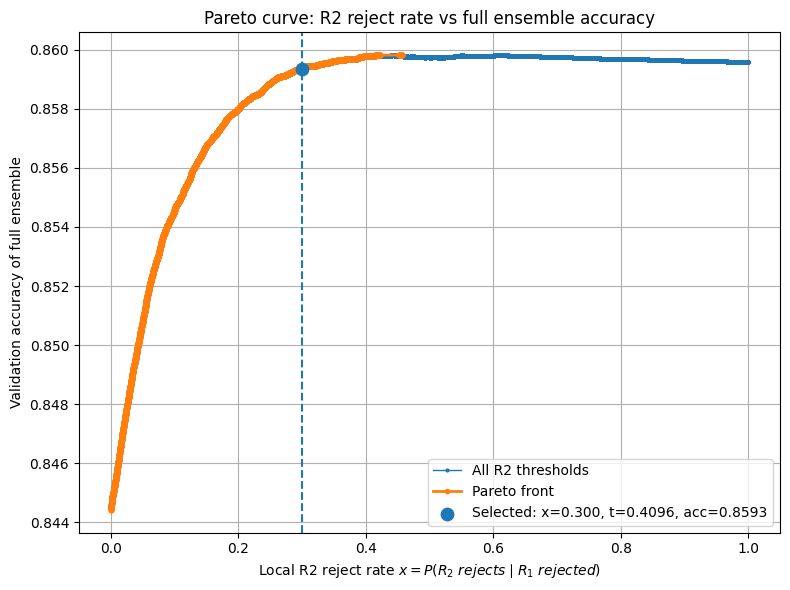

In [31]:
# ------------------------------------------------------------
# Cell 4: Main Pareto plot: local R2 reject rate vs ensemble accuracy
# ------------------------------------------------------------
# This is the main plot for choosing the final R2 reject rate / threshold.

plt.figure(figsize=(8, 6))

plt.plot(
    operating_df["local_r2_reject_rate"],
    operating_df["ensemble_acc"],
    marker="o",
    markersize=2,
    linewidth=1,
    label="All R2 thresholds",
)

plt.plot(
    pareto_df["local_r2_reject_rate"],
    pareto_df["ensemble_acc"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Pareto front",
)

plt.scatter(
    [selected_local_r2_rate],
    [selected_acc],
    s=80,
    zorder=5,
    label=(
        f"Selected: x={selected_local_r2_rate:.3f}, "
        f"t={selected_threshold:.4f}, acc={selected_acc:.4f}"
    ),
)

plt.axvline(selected_local_r2_rate, linestyle="--", linewidth=1.5)
plt.xlabel(r"Local R2 reject rate $x = P(R_2\ rejects \mid R_1\ rejected)$")
plt.ylabel("Validation accuracy of full ensemble")
plt.title("Pareto curve: R2 reject rate vs full ensemble accuracy")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


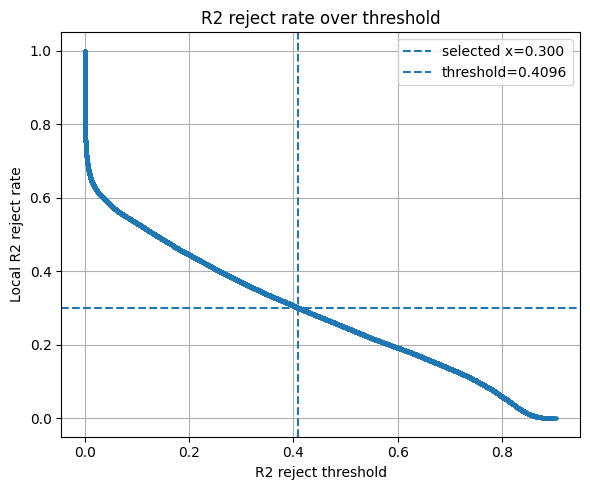

In [32]:
# ------------------------------------------------------------
# Cell 5: Threshold mapping plots
# ------------------------------------------------------------
# These plots show which threshold corresponds to which local R2 reject rate.

fig, ax1 = plt.subplots(1, figsize=(6, 5))

finite_df = operating_df[np.isfinite(operating_df["threshold"])].copy()

ax1.plot(
    finite_df["threshold"],
    finite_df["local_r2_reject_rate"],
    marker="o",
    markersize=2,
    linewidth=1,
)
ax1.axhline(selected_local_r2_rate, linestyle="--", linewidth=1.5, label=f"selected x={selected_local_r2_rate:.3f}")
ax1.axvline(selected_threshold, linestyle="--", linewidth=1.5, label=f"threshold={selected_threshold:.4f}")
ax1.set_xlabel("R2 reject threshold")
ax1.set_ylabel("Local R2 reject rate")
ax1.set_title("R2 reject rate over threshold")
ax1.grid(True)
ax1.legend()

# ax2.plot(
#     finite_df["threshold"],
#     finite_df["ensemble_acc"],
#     marker="o",
#     markersize=2,
#     linewidth=1,
# )
# ax2.axvline(selected_threshold, linestyle="--", linewidth=1.5, label=f"threshold={selected_threshold:.4f}")
# ax2.scatter([selected_threshold], [selected_acc], s=80, zorder=5)
# ax2.set_xlabel("R2 reject threshold")
# ax2.set_ylabel("Validation accuracy of full ensemble")
# ax2.set_title("Ensemble accuracy over R2 threshold")
# ax2.grid(True)
# ax2.legend()

plt.tight_layout()
plt.show()


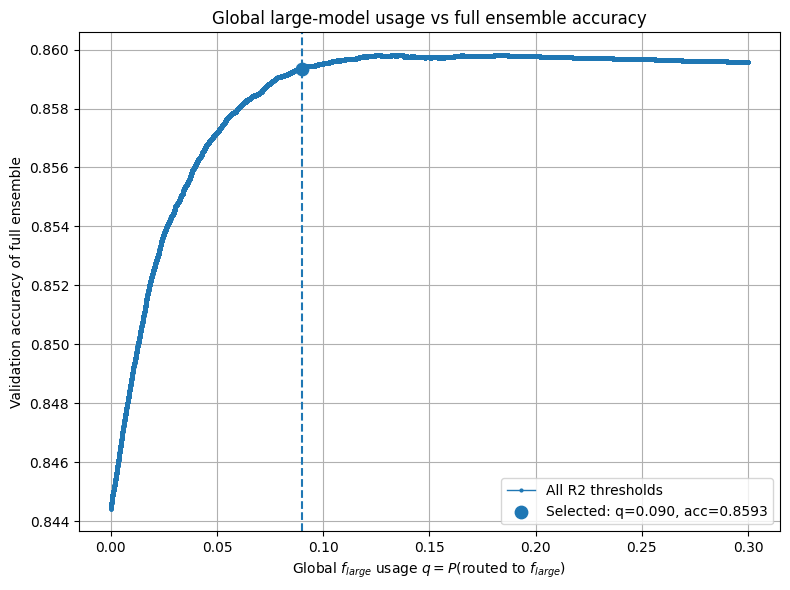

In [33]:
# ------------------------------------------------------------
# Cell 6: Global f_large usage plot
# ------------------------------------------------------------
# This is useful for reporting how many validation samples are actually routed to f_large.
# It is NOT the same as the local R2 reject rate.

plt.figure(figsize=(8, 6))

plt.plot(
    operating_df["global_large_rate"],
    operating_df["ensemble_acc"],
    marker="o",
    markersize=2,
    linewidth=1,
    label="All R2 thresholds",
)

plt.scatter(
    [selected_global_large_rate],
    [selected_acc],
    s=80,
    zorder=5,
    label=(
        f"Selected: q={selected_global_large_rate:.3f}, "
        f"acc={selected_acc:.4f}"
    ),
)

plt.axvline(selected_global_large_rate, linestyle="--", linewidth=1.5)
plt.xlabel(r"Global $f_{large}$ usage $q = P(\mathrm{routed\ to\ } f_{large})$")
plt.ylabel("Validation accuracy of full ensemble")
plt.title("Global large-model usage vs full ensemble accuracy")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Latency limit

The latency plot uses the same x-axis as the main Pareto plot: local R2 reject rate.  
The measured R1 reject rate `p1` is used, so the latency line represents the full cascade expectation, not only the R2 branch.


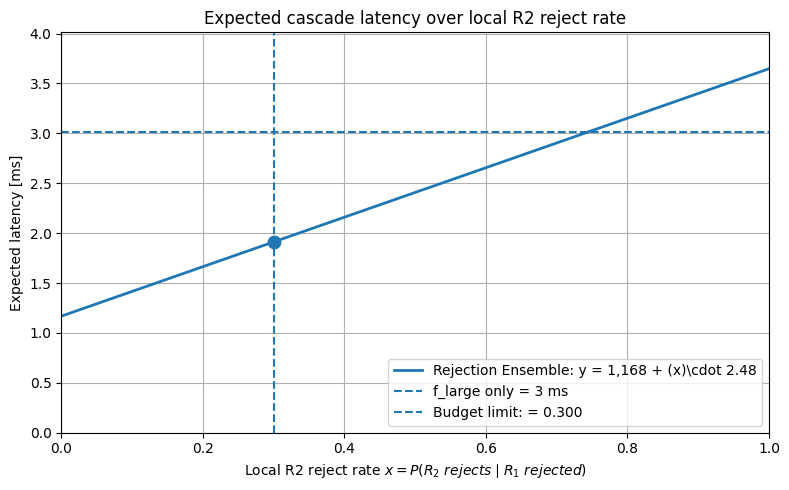

Latency constants [ms]:
  T_R1:             0.210
  T_SMALL_UNTIL_R1: 0.250
  T_SMALL_REST:     0.130
  T_DEDISP:         0.520
  T_R2:             0.210
  T_MID_UNTIL_R2:   0.380
  T_MID_REST:       0.100
  T_LARGE:          2.480

Latency summary:
  R1 reject rate p1:              0.3000
  latency at x=0.0:               1.1680 ms
  latency at x=1.0:               3.6480 ms
  selected x:                     0.3000
  selected expected latency:      1.9120 ms
  f_large-only latency:           2.4800 ms
  selected latency / f_large:     0.7710


In [34]:
# ------------------------------------------------------------
# Cell 7: Latency graph for the selected R2 reject rate
# ------------------------------------------------------------


x_grid = np.linspace(0.0, 1.0, 500)
y_latency = np.array([latency_from_local_r2_reject_rate(xi) for xi in x_grid])

latency_at_x0 = latency_from_local_r2_reject_rate(0.0)
latency_at_x1 = latency_from_local_r2_reject_rate(1.0)

plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    y_latency,
    linewidth=2,
    label="Rejection Ensemble: y = 1,168 + (x)\cdot 2.48",
)

plt.axhline(
    T_LARGE+T_DEDISP+0.01,
    linestyle="--",
    linewidth=1.5,
    label=f"f_large only = 3 ms",
)



plt.axvline(
    selected_local_r2_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Budget limit: = {selected_local_r2_rate:.3f}",
)

plt.scatter([selected_local_r2_rate], [selected_latency], s=80, zorder=5)


plt.xlabel(r"Local R2 reject rate $x = P(R_2\ rejects \mid R_1\ rejected)$")
plt.ylabel("Expected latency [ms]")
plt.title("Expected cascade latency over local R2 reject rate")
plt.grid(True)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, max(T_LARGE, y_latency.max()) * 1.10)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print("Latency constants [ms]:")
print(f"  T_R1:             {T_R1:.3f}")
print(f"  T_SMALL_UNTIL_R1: {T_SMALL_UNTIL_R1:.3f}")
print(f"  T_SMALL_REST:     {T_SMALL_REST:.3f}")
print(f"  T_DEDISP:         {T_DEDISP:.3f}")
print(f"  T_R2:             {T_R2:.3f}")
print(f"  T_MID_UNTIL_R2:   {T_MID_UNTIL_R2:.3f}")
print(f"  T_MID_REST:       {T_MID_REST:.3f}")
print(f"  T_LARGE:          {T_LARGE:.3f}")
print()
print("Latency summary:")
print(f"  R1 reject rate p1:              {p1:.4f}")
print(f"  latency at x=0.0:               {latency_at_x0:.4f} ms")
print(f"  latency at x=1.0:               {latency_at_x1:.4f} ms")
print(f"  selected x:                     {selected_local_r2_rate:.4f}")
print(f"  selected expected latency:      {selected_latency:.4f} ms")
print(f"  f_large-only latency:           {T_LARGE:.4f} ms")
print(f"  selected latency / f_large:     {selected_latency / T_LARGE:.4f}")


In [35]:
# ------------------------------------------------------------
# Cell 8: Compact table for thesis reporting
# ------------------------------------------------------------

report_row = pd.DataFrame([{
    "r1_threshold": r1_threshold,
    "r1_reject_rate_p1": p1,
    "r2_threshold": selected_threshold,
    "local_r2_reject_rate_x": selected_local_r2_rate,
    "global_large_rate_q": selected_global_large_rate,
    "ensemble_val_acc": selected_acc,
    "expected_latency_ms": selected_latency,
    "large_only_latency_ms": T_LARGE,
}])

report_row.to_csv("artifacts/operating_points/r2_selected_operating_point.csv", index=False)
display(report_row)
print("Saved selected operating point to artifacts/operating_points/r2_selected_operating_point.csv")


,r1_threshold,r1_reject_rate_p1,r2_threshold,local_r2_reject_rate_x,global_large_rate_q,ensemble_val_acc,expected_latency_ms,large_only_latency_ms
0,0.542446,0.300002,0.40963,0.3,0.090001,0.85934,1.912,2.48


Saved selected operating point to artifacts/operating_points/r2_selected_operating_point.csv


# Model comparison at a fixed reject rate

The operating point is selected by rejecting exactly the top-k samples with the highest reject scores.

In [36]:
def metrics_at_reject_rate(y_true, scores, target_reject_rate=0.20):
    """Compute reject-class metrics after selecting the highest-scoring top-k samples."""
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    scores = np.asarray(scores).reshape(-1).astype(float)

    if y_true.size != scores.size:
        raise ValueError(f"y_true and scores must have equal length, got {y_true.size} and {scores.size}.")
    if y_true.size == 0:
        raise ValueError("y_true and scores must not be empty.")
    if not 0.0 <= target_reject_rate <= 1.0:
        raise ValueError("target_reject_rate must be between 0 and 1.")
    if not np.isfinite(scores).all():
        raise ValueError("scores must contain only finite values.")

    n_samples = y_true.size
    k = int(np.rint(target_reject_rate * n_samples))
    k = int(np.clip(k, 0, n_samples))

    # Stable sorting makes the exact top-k choice deterministic when scores are tied.
    top_indices = np.argsort(-scores, kind="stable")[:k]
    y_pred = np.zeros(n_samples, dtype=int)
    y_pred[top_indices] = 1

    threshold = float(scores[top_indices[-1]]) if k > 0 else float("inf")
    precision_reject = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_reject = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_reject = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "target_reject_rate": float(target_reject_rate),
        "achieved_reject_rate": float(y_pred.mean()),
        "threshold": threshold,
        "k": k,
        "precision_reject": float(precision_reject),
        "recall_reject": float(recall_reject),
        "f1_reject": float(f1_reject),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def compare_models_at_reject_rate(results, y_true, model_names, target_reject_rate=0.20):
    model_info = {
        "conv_mlp": {"latency_ms": 0.32, "params": 445_698},
        "resnet_small_64": {"latency_ms": 0.93, "params": 1_142_274},
    }
    f_mid_latency_ms = 0.63
    f_large_latency_ms = 3.24
    rows = []

    for model_name in model_names:
        if model_name not in results:
            raise KeyError(f"No evaluation result found for {model_name!r}.")
        if model_name not in model_info:
            raise KeyError(f"No latency/parameter metadata defined for {model_name!r}.")

        result = results[model_name]
        metrics = metrics_at_reject_rate(
            y_true, result["scores"], target_reject_rate=target_reject_rate
        )
        rejector_latency_ms = model_info[model_name]["latency_ms"]
        pipeline_latency_ms = (
            f_mid_latency_ms
            + rejector_latency_ms
            + metrics["achieved_reject_rate"] * f_large_latency_ms
        )

        rows.append({
            "model_name": model_name,
            "target_reject_rate": metrics["target_reject_rate"],
            "achieved_reject_rate": metrics["achieved_reject_rate"],
            "threshold": metrics["threshold"],
            "precision_reject": metrics["precision_reject"],
            "recall_reject": metrics["recall_reject"],
            "f1_reject": metrics["f1_reject"],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
            "ap": float(result["ap"]),
            "positive_rate": float(result["positive_rate"]),
            "rejector_latency_ms": rejector_latency_ms,
            "params": model_info[model_name]["params"],
            "pipeline_latency_ms": pipeline_latency_ms,
        })

    return pd.DataFrame(rows)


def plot_pr_with_reject_rate_point(result, point_metrics, model_name, save_path=None):
    precision = np.asarray(result["precision"])
    recall = np.asarray(result["recall"])
    ap = float(result["ap"])
    positive_rate = float(result["positive_rate"])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall, precision, lw=2, label=f"{model_name} (AP = {ap:.4f})")
    ax.axhline(
        positive_rate, color="gray", linestyle="--",
        label=f"Random baseline = {positive_rate:.4f}",
    )
    ax.scatter(
        point_metrics["recall_reject"],
        point_metrics["precision_reject"],
        s=90, color="red", zorder=5,
        label=f"Top-k reject rate = {point_metrics['achieved_reject_rate']:.1%}",
    )
    ax.set_xlabel("Recall for reject class")
    ax.set_ylabel("Precision for reject class")
    ax.set_title(f"Precision-Recall Curve: {model_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, ax



--- Evaluating conv_mlp ---


100%|██████████| 49/49 [01:17<00:00,  1.58s/it]


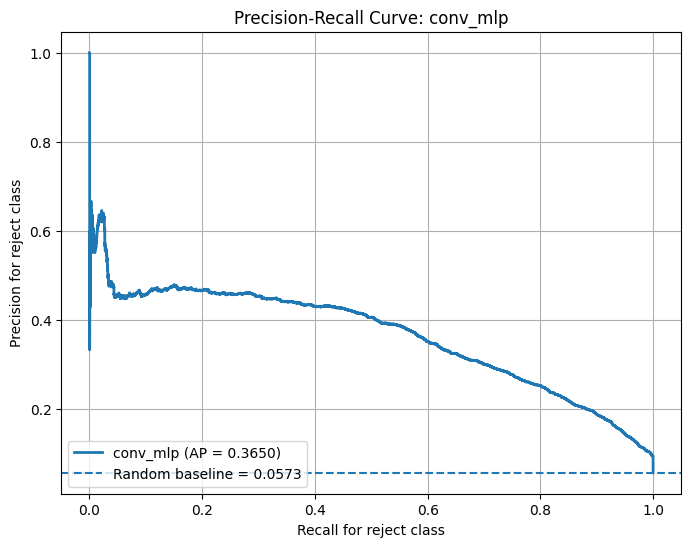

Positive rate / true reject share: 0.0573
Average Precision AP:             0.3650
Trapezoidal PR-AUC:               0.3647

Metrics at threshold = 0.5000
Positive rate / true reject share: 0.0573
Predicted reject rate:            0.2481
Precision reject=1:               0.2030
Recall reject=1:                  0.8786
F1 reject=1:                      0.3298

Confusion matrix for routing target
Rows = true, columns = predicted
          pred_accept   pred_reject
true_accept        36821          9776
true_reject          344          2490


KeyError: "No evaluation result found for 'resnet_small_64'."

In [37]:
results = {}
results["conv_mlp"] = evaluate_rejector_model("conv_mlp")


comparison_20 = compare_models_at_reject_rate(
    results=results,
    y_true=y_true,
    model_names=["conv_mlp", "resnet_small_64"],
    target_reject_rate=0.30,
)
display(comparison_20)

for model_name in ["conv_mlp"]:
    point_metrics = metrics_at_reject_rate(
        y_true,
        results[model_name]["scores"],
        target_reject_rate=0.20,
    )
    plot_pr_with_reject_rate_point(
        results[model_name],
        point_metrics,
        model_name,
        save_path=f"pr_curve_{model_name}_reject_rate_20.png",
    )
